In [23]:
import numpy as np
import pint
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
unit = pint.UnitRegistry()

magnitude = lambda x: x.magnitude if isinstance(x, pint.Quantity) else x
tounit = lambda x: lambda y: y.to(x)
assign_unit = lambda x: lambda y: y * x
assign_quantitiy = lambda t, quantity: unit.Quantity(t, quantity)


In [24]:
data1 = pd.read_csv("../DATA/data_table1.csv")
data2 = pd.read_csv("../DATA/data_table2.csv")

In [25]:
data1

,t_k(C),t_w(C),m_w(ml),t_m(C)
0,14,20,300,15
1,18,40,300,39
2,27,49,300,43


In [26]:

data1["t_k(C)"] = data1["t_k(C)"].apply(lambda t: assign_quantitiy(t, unit.degree_Celsius))
data1["t_w(C)"] = data1["t_w(C)"].apply(lambda t: assign_quantitiy(t, unit.degree_Celsius))
data1["t_m(C)"] = data1["t_m(C)"].apply(lambda t: assign_quantitiy(t, unit.degree_Celsius))
data1["m_w(ml)"] = data1["m_w(ml)"].apply(assign_unit(unit.milliliter))

In [27]:
data2

,Material,t_k(C),t_2(C),t_m(C),m_p(g),m_w(ml)
0,Brass,20,76,22,179,300
1,Aluminum,20,83,26,180,300
2,Iron,23,85,26,180,300


In [28]:
data2["t_k(C)"] = data2["t_k(C)"].apply(lambda t: assign_quantitiy(t, unit.degree_Celsius))
data2["t_2(C)"] = data2["t_2(C)"].apply(lambda t: assign_quantitiy(t, unit.degree_Celsius))
data2["t_m(C)"] = data2["t_m(C)"].apply(lambda t: assign_quantitiy(t, unit.degree_Celsius))
data2["m_p(g)"] = data2["m_p(g)"].apply(lambda t: assign_quantitiy(t, unit.gram))
data2["m_w(ml)"] = data2["m_w(ml)"].apply(assign_unit(unit.milliliter))

# Part 1

$$C_k = c_w m_w \frac{t_w - t_m}{t_w - t_k} $$

In [29]:
c_w = 4.187 * unit.joule / (unit.gram * unit.kelvin) # this is the specific heat capacity of water. value taken from lab manual
C_k = lambda t_k, t_w, m_w,t_m: c_w*m_w*(t_w-t_m)/(t_w-t_k) # this is the formula for calculating the specific heat capacity of the metal. formula taken from lab manual (EQ7)


In [30]:
data1["m_w(g)"] = data1["m_w(ml)"].apply(lambda v: v* (unit.gram/unit.milliliter))

In [31]:
data1["C_k(J/K)"] = data1.apply(lambda row: C_k(row["t_k(C)"], row["t_w(C)"], row["m_w(g)"], row["t_m(C)"]).to(unit.joule / (unit.kelvin)), axis=1)


In [32]:
C_k_average = data1["C_k(J/K)"].apply(magnitude).mean() * unit.joule / unit.kelvin
C_k_average

<Quantity(482.139394, 'joule / kelvin')>

In [33]:
data1

,t_k(C),t_w(C),m_w(ml),t_m(C),m_w(g),C_k(J/K)
0,14 degree_Celsius,20 degree_Celsius,300 milliliter,15 degree_Celsius,300 gram,1046.7500000000002 joule / kelvin
1,18 degree_Celsius,40 degree_Celsius,300 milliliter,39 degree_Celsius,300 gram,57.09545454545455 joule / kelvin
2,27 degree_Celsius,49 degree_Celsius,300 milliliter,43 degree_Celsius,300 gram,342.57272727272726 joule / kelvin


# Part 2

In [34]:
data2["m_w(g)"] = data2["m_w(ml)"].apply(lambda v: v* (unit.gram/unit.milliliter))
data2

,Material,t_k(C),t_2(C),t_m(C),m_p(g),m_w(ml),m_w(g)
0,Brass,20 degree_Celsius,76 degree_Celsius,22 degree_Celsius,179 gram,300 milliliter,300 gram
1,Aluminum,20 degree_Celsius,83 degree_Celsius,26 degree_Celsius,180 gram,300 milliliter,300 gram
2,Iron,23 degree_Celsius,85 degree_Celsius,26 degree_Celsius,180 gram,300 milliliter,300 gram


$$c = \frac{(c_w m_w + C_{k\text{ average}})(t_m - t_k)}{m_p(t_2 - t_m)}$$

note: the lab manual presents this formula incorrectly! but the corrected version is derived from the conservation of energy as follows:

$$Q_{\text{lost}} = Q_{\text{gained}}$$
$$Q_{\text{sample}} = Q_{\text{water}} + Q_{\text{calorimeter}}$$

The heat transfer for each component based on the formula $Q = mc\Delta T$ (or $Q = C \Delta T$ for heat capacity C) [W. Greiner, L. Neise, and H. Stöcker, Thermodynamics and Statistical Mechanics (Springer, New York, 1995), p. 16]:

$$Q_{\text{sample}} = m_p c (t_2 - t_m)$$
$$Q_{\text{water}} = m_w c_w (t_m - t_k)$$
$$Q_{\text{calorimeter}} = C_k (t_m - t_k)$$

Energy Balance: 

$$m_p \cdot c \cdot (t_2 - t_m) = m_w \cdot c_w \cdot (t_m - t_k) + C_k \cdot (t_m - t_k)$$
so 
$$m_p \cdot c \cdot (t_2 - t_m) = (m_w \cdot c_w + C_k)(t_m - t_k)$$

Therefor:

$$c = \frac{(m_w \cdot c_w + C_k)(t_m - t_k)}{m_p(t_2 - t_m)}$$

In [35]:
c = lambda m_w, m_p, t_2, t_m, t_k: (c_w*m_w + C_k_average)*(t_m-t_k)/(m_p*(t_2-t_m))

In [36]:
data2["c(J/gK)"] = data2.apply(lambda row: c(row["m_w(g)"], row["m_p(g)"], row["t_2(C)"], row["t_m(C)"], row["t_k(C)"]).to(unit.joule / (unit.gram * unit.kelvin)), axis=1)
data2

,Material,t_k(C),t_2(C),t_m(C),m_p(g),m_w(ml),m_w(g),c(J/gK)
0,Brass,20 degree_Celsius,76 degree_Celsius,22 degree_Celsius,179 gram,300 milliliter,300 gram,0.3596605408523472 joule / gram / kelvin
1,Aluminum,20 degree_Celsius,83 degree_Celsius,26 degree_Celsius,180 gram,300 milliliter,300 gram,1.016514265461634 joule / gram / kelvin
2,Iron,23 degree_Celsius,85 degree_Celsius,26 degree_Celsius,180 gram,300 milliliter,300 gram,0.49102807738400966 joule / gram / kelvin


## reference: 
Accepted Specific Heat Capacity Values (J/g·K)
| Reference Source | Aluminum | Iron | Brass |
|---|---|---|---|
| HyperPhysics (GSU)[](http://hyperphysics.phy-astr.gsu.edu/hbase/Tables/sphtt.html) | 0.900 | 0.450 | 0.380 |
| Engineering ToolBox[](https://www.engineeringtoolbox.com/specific-heat-metals-d_152.html) | 0.910 | 0.450 | 0.380 |
| Misumi USA[](https://us.misumi-ec.com/blog/specific-heat-capacity-of-metals/) | 0.897 | 0.449 | 0.380 |
| LibreTexts (Chemistry)[](https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Thermodynamics_Tables/T4%3A_Specific_Heats_and_Molar_Heat_Capacities) | 0.900 | 0.449 | 0.380 |

* Engineering ToolBox. (2003). Specific Heat of Metals. www.engineeringtoolbox.com
* LibreTexts Chemistry. (2020). T4: Specific Heats and Molar Heat Capacities. chem.libretexts.org
* Misumi USA. (2022). Specific Heat Capacity of Metals. us.misumi-ec.com
* Nave, R. (2017). Table of Specific Heats. HyperPhysics, Georgia State University. hyperphysics.phy-astr.gsu.edu


In [37]:
reference_values = {
    "Aluminum": sum([0.897, 0.900, 0.910, 0.900])/4 * unit.joule / (unit.gram * unit.kelvin),
    "Iron": sum([0.449, 0.450, 0.450, 0.449])/4 * unit.joule / (unit.gram * unit.kelvin),
    "Brass": 0.380 * unit.joule / (unit.gram * unit.kelvin)
}
reference_values = pd.DataFrame(list(reference_values.items()), columns=["Material", "c(J/gK)"])

In [38]:
data2

,Material,t_k(C),t_2(C),t_m(C),m_p(g),m_w(ml),m_w(g),c(J/gK)
0,Brass,20 degree_Celsius,76 degree_Celsius,22 degree_Celsius,179 gram,300 milliliter,300 gram,0.3596605408523472 joule / gram / kelvin
1,Aluminum,20 degree_Celsius,83 degree_Celsius,26 degree_Celsius,180 gram,300 milliliter,300 gram,1.016514265461634 joule / gram / kelvin
2,Iron,23 degree_Celsius,85 degree_Celsius,26 degree_Celsius,180 gram,300 milliliter,300 gram,0.49102807738400966 joule / gram / kelvin


In [39]:
# errors calculation from the reference values
data2 = data2.merge(reference_values, left_on="Material", right_on="Material", how="left")
data2["Error(%)"] = data2.apply(lambda row: abs(row["c(J/gK)_x"] - row["c(J/gK)_y"])/row["c(J/gK)_y"]*100, axis=1)
data2[["Material", "c(J/gK)_x", "c(J/gK)_y", "Error(%)"]]

,Material,c(J/gK)_x,c(J/gK)_y,Error(%)
0,Brass,0.3596605408523472 joule / gram / kelvin,0.38 joule / gram / kelvin,5.3524892493823115 dimensionless
1,Aluminum,1.016514265461634 joule / gram / kelvin,0.90175 joule / gram / kelvin,12.726838421029537 dimensionless
2,Iron,0.49102807738400966 joule / gram / kelvin,0.4495 joule / gram / kelvin,9.238726892994361 dimensionless


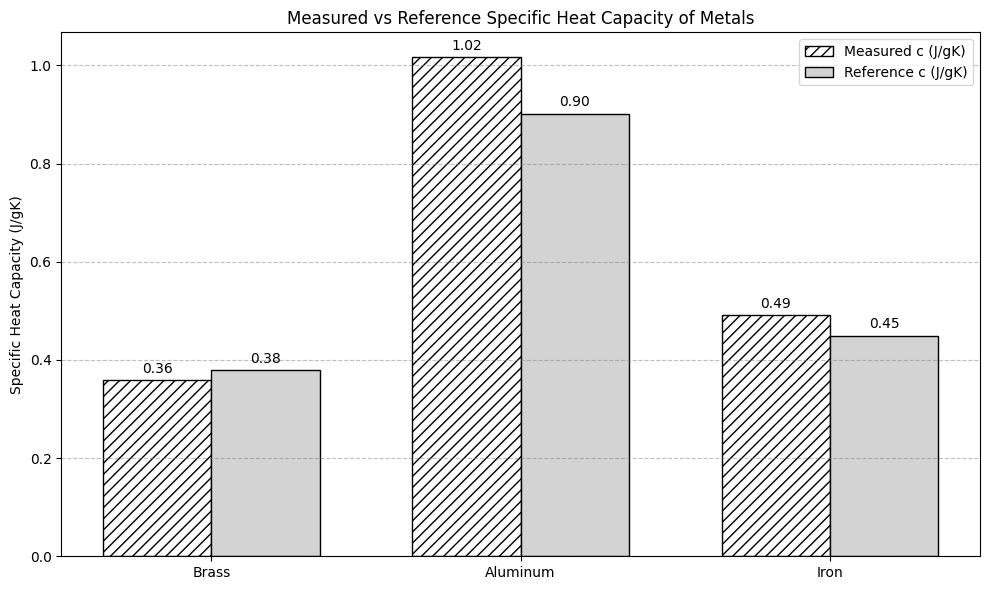

In [68]:
# Plotting the results
path = Path("../plots")
path.mkdir(parents=True, exist_ok=True)

# Data preparation
materials = data2["Material"]
measured = data2["c(J/gK)_x"].apply(magnitude)
reference = data2["c(J/gK)_y"].apply(magnitude)

x = np.arange(len(materials))  # the label locations
width = 0.35  # the width of the bars

plt.figure(figsize=(10, 6))
# Black and white compatible styling: using patterns (hatches) and grayscale colors
rects1 = plt.bar(x - width/2, measured, width, label="Measured c (J/gK)", color='white', edgecolor='black', hatch='///')
rects2 = plt.bar(x + width/2, reference, width, label="Reference c (J/gK)", color='lightgray', edgecolor='black')

# Add some text for labels, title and custom x-axis tick labels, etc.
plt.ylabel("Specific Heat Capacity (J/gK)")
plt.title("Measured vs Reference Specific Heat Capacity of Metals")
plt.xticks(x, materials)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

# Add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig("../plots/specific_heat_comparison.png", dpi=300)
plt.show()

In [67]:
Path("../report/tables").mkdir(parents=True, exist_ok=True)
# export the results to csv files
tables_dir = Path("../report/tables")

# Clean units for CSV export: 
def clean_for_csv(df):
    new_df = df.copy()
    for col in new_df.columns:
        if new_df[col].dtype == 'object': # Check if it contains pint quantities
            try:
                new_df[col] = new_df[col].apply(magnitude)
            except:
                pass # keep as is if not a quantity
    return new_df

table1_out = data1[["t_k(C)", "t_w(C)", "t_m(C)", "m_w(ml)", "C_k(J/K)"]]
cleaned_table1 = clean_for_csv(table1_out)
cleaned_table1.to_csv(tables_dir / 'table1_calorimeter_heat_capacity.csv', index=False)

table2_out = data2[["Material", "t_k(C)", "t_2(C)", "t_m(C)", "m_p(g)", "m_w(ml)", "c(J/gK)_x", "c(J/gK)_y", "Error(%)"]]
cleaned_table2 = clean_for_csv(table2_out)
cleaned_table2.to_csv(tables_dir / 'table2_specific_heat.csv', index=False)

# Summary scalars (+ simple uncertainty estimates derived from repeated trials)
# Corrected column access: 'C_k(J/K)' instead of 'C_k_J_per_K'
Ck_vals = cleaned_table1['C_k(J/K)'].to_numpy(dtype=float)

Ck_mean = float(np.mean(Ck_vals)) if len(Ck_vals) else float('nan')
Ck_std = float(np.std(Ck_vals, ddof=1)) if len(Ck_vals) > 1 else 0.0

summary_scalars = pd.DataFrame(
    [
        ("C_k_mean", Ck_mean),
        ("C_k_std", Ck_std)
    ]
)
summary_scalars.to_csv(tables_dir / 'summary_scalars.csv', index=False)